# Logarithms

## Contents
1. [Definition](#1.-Definition)
2. [Conditions and Special Values](#2.-Conditions-and-Special-Values)
3. [Common Log, Natural Log and the Number e](#3.-Common-Log,-Natural-Log-and-the-Number-e)
4. [Laws of Logarithms](#4.-Laws-of-Logarithms)
5. [Further Properties](#5.-Further-Properties)
6. [Simplifying and Evaluating](#6.-Simplifying-and-Evaluating)
7. [Graphs and Monotonicity](#7.-Graphs-and-Monotonicity)
8. [Exponential Equations](#8.-Exponential-Equations)
9. [Logarithmic Equations](#9.-Logarithmic-Equations)
10. [Logarithmic Inequalities](#10.-Logarithmic-Inequalities)
11. [Characteristic, Mantissa and Log Tables](#11.-Characteristic,-Mantissa-and-Log-Tables)
12. [Applications](#12.-Applications)
13. [Common Mistakes](#13.-Common-Mistakes)
14. [Formula Sheet](#14.-Formula-Sheet)
15. [Practice Problems (with Answers)](#15.-Practice-Problems-(with-Answers))

Prerequisite: laws of exponents (see `algebra.ipynb`, Section 3). The code cells use SymPy, NumPy and Matplotlib.

In [1]:
import math
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

x, t = sp.symbols("x t", real=True)
log = lambda v, base=10: sp.log(v, base)      # exact log with any base (default: common log)
print("Ready.")

Ready.


## 1. Definition

A logarithm answers the question: **"to what power must I raise the base to get this number?"**

$$\boxed{\log_a N = x \iff a^x = N} \qquad (a > 0,\ a \neq 1,\ N > 0)$$

- $a$ is the **base**, $N$ the **argument**, $x$ the **logarithm**.
- Logarithm and exponent are **inverse operations**: $\log_a(a^x) = x$ and $a^{\log_a N} = N$.

### Converting between forms

| Exponential form | Logarithmic form |
|------------------|------------------|
| $2^5 = 32$ | $\log_2 32 = 5$ |
| $10^{-2} = 0.01$ | $\log_{10} 0.01 = -2$ |
| $81^{1/4} = 3$ | $\log_{81} 3 = \tfrac{1}{4}$ |
| $\left(\tfrac{1}{3}\right)^{-4} = 81$ | $\log_{1/3} 81 = -4$ |
| $e^0 = 1$ | $\ln 1 = 0$ |

### Evaluating from the definition
Write both the base and the argument as powers of the same number.

- $\log_4 8$: $\;4^x = 8 \Rightarrow 2^{2x} = 2^3 \Rightarrow x = \tfrac{3}{2}$
- $\log_{\sqrt{2}} 8$: $\;(\sqrt{2})^x = 2^{x/2} = 2^3 \Rightarrow x = 6$
- $\log_{0.5} 16$: $\;2^{-x} = 2^4 \Rightarrow x = -4$
- $\log_2(\log_3 81) = \log_2 4 = 2$

In [2]:
for expr in [log(32, 2), log(sp.Rational(1, 100)), log(3, 81), log(81, sp.Rational(1, 3)),
             log(8, 4), log(8, sp.sqrt(2)), log(16, sp.Rational(1, 2)), log(log(81, 3), 2)]:
    print(f"{str(expr):<30} = {sp.nsimplify(sp.simplify(expr))}")

5                              = 5
-2                             = -2
log(3)/log(81)                 = 1/4
-log(81)/log(3)                = -4
log(2)/log(4) + 1              = 3/2
log(8)/log(sqrt(2))            = 6
-log(16)/log(2)                = -4
2                              = 2


## 2. Conditions and Special Values

For $\log_a N$ to be defined (as a real number):

| Condition | Reason |
|-----------|--------|
| $N > 0$ | $a^x$ is always positive, so it can never equal 0 or a negative number |
| $a > 0$ | Negative bases give non-real values for fractional powers |
| $a \neq 1$ | $1^x = 1$ for every $x$, so $\log_1 N$ is meaningless |

**These conditions must be checked in every equation and inequality** — they are the source of most "extraneous" answers.

### Special values

| Value | Result | Why |
|-------|--------|-----|
| $\log_a 1$ | $0$ | $a^0 = 1$ |
| $\log_a a$ | $1$ | $a^1 = a$ |
| $\log_a a^k$ | $k$ | definition |
| $a^{\log_a N}$ | $N$ | inverse operations |
| $\log_a \tfrac{1}{a}$ | $-1$ | $a^{-1} = \tfrac{1}{a}$ |

### Sign of $\log_a N$

| | $0 < N < 1$ | $N = 1$ | $N > 1$ |
|---|---|---|---|
| Base $a > 1$ | negative | 0 | positive |
| Base $0 < a < 1$ | positive | 0 | negative |

Rule of thumb: $\log_a N > 0$ when $a$ and $N$ are **on the same side of 1**.

## 3. Common Log, Natural Log and the Number e

| Name | Notation | Base | Used in |
|------|----------|------|---------|
| Common logarithm | $\log N$ or $\log_{10} N$ | 10 | Log tables, pH, decibels, Richter scale |
| Natural logarithm | $\ln N$ or $\log_e N$ | $e$ | Calculus, continuous growth, science |
| Binary logarithm | $\log_2 N$ (or $\lg N$) | 2 | Computer science |

### The number e
$$e = \lim_{n \to \infty}\left(1 + \frac{1}{n}\right)^n = 1 + \frac{1}{1!} + \frac{1}{2!} + \frac{1}{3!} + \dots \approx 2.71828$$

$e$ is irrational. It appears whenever growth is **continuous** (interest compounded every instant, population growth, radioactive decay).

### Converting between ln and log
$$\ln N = \frac{\log N}{\log e} \approx 2.303 \log N, \qquad \log N = \frac{\ln N}{\ln 10} \approx 0.4343 \ln N$$

**Values worth memorising:** $\log 2 \approx 0.3010$, $\log 3 \approx 0.4771$, $\log 7 \approx 0.8451$, $\ln 2 \approx 0.6931$, $\ln 10 \approx 2.3026$.

In [3]:
for n in [1, 10, 100, 1000, 10**6]:
    print(f"(1 + 1/{n})^{n} = {(1 + 1/n)**n:.6f}")
print("e        =", f"{math.e:.6f}")
print("ln 10    =", f"{math.log(10):.4f}", "| log e =", f"{math.log10(math.e):.4f}")
print("log 2, log 3, log 7 =", [round(math.log10(v), 4) for v in (2, 3, 7)])

(1 + 1/1)^1 = 2.000000
(1 + 1/10)^10 = 2.593742
(1 + 1/100)^100 = 2.704814
(1 + 1/1000)^1000 = 2.716924
(1 + 1/1000000)^1000000 = 2.718280
e        = 2.718282
ln 10    = 2.3026 | log e = 0.4343
log 2, log 3, log 7 = [0.301, 0.4771, 0.8451]


## 4. Laws of Logarithms

For $a > 0$, $a \neq 1$ and $m, n > 0$:

| Law | Rule |
|-----|------|
| Product | $\log_a(mn) = \log_a m + \log_a n$ |
| Quotient | $\log_a\left(\dfrac{m}{n}\right) = \log_a m - \log_a n$ |
| Power | $\log_a(m^k) = k\log_a m$ (any real $k$) |
| Root (special case) | $\log_a \sqrt[k]{m} = \dfrac{1}{k}\log_a m$ |
| Reciprocal argument | $\log_a\left(\dfrac{1}{m}\right) = -\log_a m$ |

### Proofs
Let $\log_a m = x$ and $\log_a n = y$, so $m = a^x$, $n = a^y$.
- **Product:** $mn = a^{x + y} \Rightarrow \log_a(mn) = x + y$.
- **Quotient:** $\dfrac{m}{n} = a^{x - y} \Rightarrow \log_a\dfrac{m}{n} = x - y$.
- **Power:** $m^k = a^{kx} \Rightarrow \log_a m^k = kx$.

The laws of logs are just the laws of exponents ($a^xa^y = a^{x+y}$, etc.) written the other way round.

### Expanding and condensing
- **Expand:** $\log\dfrac{x^3\sqrt{y}}{z^2} = 3\log x + \tfrac{1}{2}\log y - 2\log z$
- **Condense:** $2\log 3 + \log 4 - \log 6 = \log\dfrac{9 \cdot 4}{6} = \log 6$

**Careful with powers on the whole log:** $(\log m)^2 \neq 2\log m$; only $\log(m^2) = 2\log m$.

In [4]:
X, Y, Z = sp.symbols("X Y Z", positive=True)
print(sp.expand_log(sp.log(X**3 * sp.sqrt(Y) / Z**2)))
print(sp.logcombine(2*sp.log(3) + sp.log(4) - sp.log(6), force=True))

3*log(X) + log(Y)/2 - 2*log(Z)
log(6)


## 5. Further Properties

| Property | Rule |
|----------|------|
| **Change of base** | $\log_a N = \dfrac{\log_b N}{\log_b a}$ (any valid base $b$, usually 10 or $e$) |
| Reciprocal | $\log_a b = \dfrac{1}{\log_b a}$ |
| Chain rule | $\log_a b \cdot \log_b c = \log_a c$ |
| Power of the base | $\log_{a^m} b^n = \dfrac{n}{m}\log_a b$ |
| Reciprocal base | $\log_{1/a} b = -\log_a b$ |
| Inverse | $a^{\log_a x} = x$ |
| Swap | $a^{\log_b c} = c^{\log_b a}$ |

**Proof of change of base.** Let $\log_a N = x$, so $a^x = N$. Take $\log_b$ of both sides: $x\log_b a = \log_b N$. ∎

**Proof of the swap property.** Take $\log_b$ of both sides: $\log_b c \cdot \log_b a$ on each side. ∎

### Examples
- $\log_8 32 = \log_{2^3} 2^5 = \tfrac{5}{3}$
- $\log_{1/2} 8 = -\log_2 8 = -3$
- $\log_2 3 \cdot \log_3 4 \cdot \log_4 5 \cdot \log_5 6 \cdot \log_6 7 \cdot \log_7 8 = \log_2 8 = 3$
- $\dfrac{1}{\log_2 6} + \dfrac{1}{\log_3 6} = \log_6 2 + \log_6 3 = \log_6 6 = 1$
- $3^{\log_3 7} = 7$
- $2^{\log_3 5} = 5^{\log_3 2}$

In [5]:
print(sp.nsimplify(sp.simplify(log(32, 8))), sp.simplify(log(8, sp.Rational(1, 2))))
chain = sp.prod([sp.log(i + 1) / sp.log(i) for i in range(2, 8)])
print("chain product =", sp.simplify(chain))
print("1/log2(6) + 1/log3(6) =", sp.simplify(1/log(6, 2) + 1/log(6, 3)))
print("3^(log3 7) =", sp.simplify(3**log(7, 3)))
print("2^(log3 5) =", round(2**math.log(5, 3), 10), " 5^(log3 2) =", round(5**math.log(2, 3), 10))

5/3 -3
chain product = 3
1/log2(6) + 1/log3(6) = 1
3^(log3 7) = 7
2^(log3 5) = 2.7605840385  5^(log3 2) = 2.7605840385


## 6. Simplifying and Evaluating

### Using known values
Given $\log 2 = 0.3010$ and $\log 3 = 0.4771$, break the number into factors of 2, 3 and 10:

| Number | Factorisation | log |
|--------|---------------|-----|
| $\log 5$ | $\tfrac{10}{2}$ | $1 - 0.3010 = 0.6990$ |
| $\log 12$ | $2^2 \cdot 3$ | $0.6020 + 0.4771 = 1.0791$ |
| $\log 72$ | $2^3 \cdot 3^2$ | $0.9030 + 0.9542 = 1.8572$ |
| $\log 1.5$ | $\tfrac{3}{2}$ | $0.4771 - 0.3010 = 0.1761$ |
| $\log 0.06$ | $\tfrac{2 \cdot 3}{100}$ | $0.7781 - 2 = -1.2219$ |

### Classic simplification
$$\log\frac{75}{16} - 2\log\frac{5}{9} + \log\frac{32}{243} = \log\left(\frac{75}{16} \cdot \frac{81}{25} \cdot \frac{32}{243}\right) = \log 2$$

### Expressing in terms of other logs
If $\log 2 = p$ and $\log 3 = q$, then $\log 60 = \log(10 \cdot 2 \cdot 3) = 1 + p + q$.

### Proving a relation
If $a^2 + b^2 = 7ab$ (with $a, b > 0$), show $\log\dfrac{a + b}{3} = \dfrac{1}{2}(\log a + \log b)$.

$(a + b)^2 = a^2 + b^2 + 2ab = 9ab \Rightarrow \left(\dfrac{a + b}{3}\right)^2 = ab$. Take logs: $2\log\dfrac{a + b}{3} = \log a + \log b$. ∎

In [6]:
l2, l3 = 0.3010, 0.4771
print("log 5 =", round(1 - l2, 4), "| log 12 =", round(2*l2 + l3, 4), "| log 72 =", round(3*l2 + 2*l3, 4),
      "| log 1.5 =", round(l3 - l2, 4), "| log 0.06 =", round(l2 + l3 - 2, 4))
print("actual:     ", [round(math.log10(v), 4) for v in (5, 12, 72, 1.5, 0.06)])
expr = sp.Rational(75, 16) * sp.Rational(9, 5)**2 * sp.Rational(32, 243)
print("classic simplification: log of", expr)

# a^2 + b^2 = 7ab with a = 1  ->  b^2 - 7b + 1 = 0
b = (7 + math.sqrt(45)) / 2
print("log((a+b)/3) =", round(math.log10((1 + b) / 3), 10), " ½(log a + log b) =", round(0.5 * math.log10(b), 10))

log 5 = 0.699 | log 12 = 1.0791 | log 72 = 1.8572 | log 1.5 = 0.1761 | log 0.06 = -1.2219
actual:      [0.699, 1.0792, 1.8573, 0.1761, -1.2218]
classic simplification: log of 2
log((a+b)/3) = 0.4179752805  ½(log a + log b) = 0.4179752805


## 7. Graphs and Monotonicity

The graph of $y = \log_a x$ is the reflection of $y = a^x$ in the line $y = x$.

| Feature | $a > 1$ | $0 < a < 1$ |
|---------|---------|-------------|
| Domain | $x > 0$ | $x > 0$ |
| Range | all reals | all reals |
| Passes through | $(1, 0)$ and $(a, 1)$ | $(1, 0)$ and $(a, 1)$ |
| Behaviour | **increasing** | **decreasing** |
| As $x \to 0^+$ | $y \to -\infty$ | $y \to +\infty$ |
| Asymptote | $y$-axis ($x = 0$) | $y$-axis |

### Why monotonicity matters
- If $a > 1$: $\;\log_a m > \log_a n \iff m > n$ (order is **kept**).
- If $0 < a < 1$: $\;\log_a m > \log_a n \iff m < n$ (order is **reversed**).

This is the key to solving log inequalities (Section 10).

### Comparing logs
- $\log_{0.5} 3$ vs $\log_{0.5} 5$: base $< 1$ → decreasing → $\log_{0.5} 3 > \log_{0.5} 5$.
- $\log_2 3$ vs $\log_3 2$: the first is $> 1$ (since $3 > 2$), the second is $< 1$ → $\log_2 3 > \log_3 2$.
- For $x > 1$, a **larger base gives a smaller log**: $\log_2 x > \ln x > \log_{10} x$.

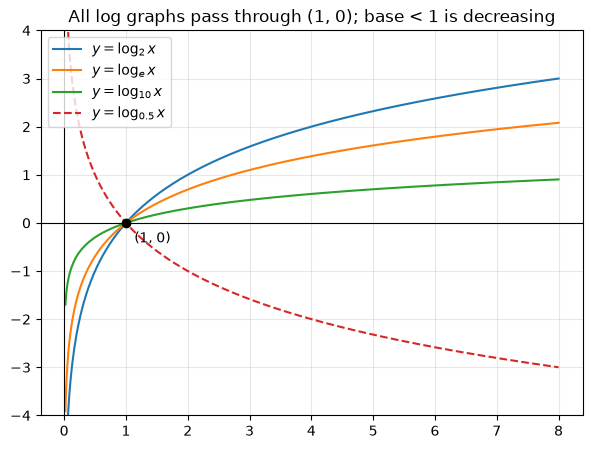

In [7]:
xs = np.linspace(0.02, 8, 500)
plt.figure(figsize=(7, 5))
for base, style in [(2, "-"), (math.e, "-"), (10, "-"), (0.5, "--")]:
    label = "e" if base == math.e else base
    plt.plot(xs, np.log(xs) / np.log(base), style, label=f"$y = \\log_{{{label}}} x$")
plt.scatter([1], [0], color="black", zorder=3); plt.annotate("(1, 0)", (1, 0), xytext=(6, -14), textcoords="offset points")
plt.axhline(0, color="black", lw=0.8); plt.axvline(0, color="black", lw=0.8)
plt.ylim(-4, 4); plt.grid(alpha=0.3); plt.legend()
plt.title("All log graphs pass through (1, 0); base < 1 is decreasing")
plt.show()

## 8. Exponential Equations

### Type 1: same base possible
Write both sides as powers of one base and equate exponents. ($2^{x+1} = 32 \Rightarrow x = 4$; see `algebra.ipynb`.)

### Type 2: different bases → take logs
**Example.** $2^x = 5 \Rightarrow x = \log_2 5 = \dfrac{\log 5}{\log 2} \approx 2.3219$.

**Example.** $3^{x + 1} = 5^x$. Take $\ln$: $(x + 1)\ln 3 = x\ln 5 \Rightarrow x(\ln 5 - \ln 3) = \ln 3 \Rightarrow x = \dfrac{\ln 3}{\ln 5 - \ln 3} \approx 2.1507$.

**Example.** $e^{2x} = 7 \Rightarrow 2x = \ln 7 \Rightarrow x = \tfrac{1}{2}\ln 7 \approx 0.9730$.

### Type 3: quadratic in disguise → substitute
**Example.** $4^x - 3 \cdot 2^x - 4 = 0$. Let $t = 2^x > 0$: $t^2 - 3t - 4 = 0 \Rightarrow t = 4$ or $t = -1$.
Reject $t = -1$ (since $2^x > 0$) → $2^x = 4 \Rightarrow x = 2$.

### Type 4: variable in both base and exponent
**Example.** $x^{\log x} = 100x$ (with $x > 0$). Take $\log$: $(\log x)^2 = 2 + \log x$.
Let $t = \log x$: $t^2 - t - 2 = 0 \Rightarrow t = 2$ or $-1$ → $x = 100$ or $x = \tfrac{1}{10}$.

In [8]:
print("2^x = 5        ->", sp.solve(sp.Eq(2**x, 5), x), "≈", round(math.log(5, 2), 4))
sol = sp.solve(sp.Eq(3**(x + 1), 5**x), x)[0]; print("3^(x+1) = 5^x  ->", sp.simplify(sol), "≈", round(float(sol), 4))
print("e^(2x) = 7     ->", sp.solve(sp.Eq(sp.exp(2*x), 7), x), "≈", round(math.log(7) / 2, 4))
print("4^x - 3·2^x - 4 = 0 ->", sp.solve(4**x - 3*2**x - 4, x))
xp = sp.symbols("xp", positive=True)
print("x^(log x) = 100x ->", sp.solve(sp.Eq(sp.log(xp, 10)**2, 2 + sp.log(xp, 10)), xp))

2^x = 5        -> [log(5)/log(2)] ≈ 2.3219
3^(x+1) = 5^x  -> -log(3)/(-log(5) + log(3)) ≈ 2.1507


e^(2x) = 7     ->

 [log(7)/2] ≈ 0.973
4^x - 3·2^x - 4 = 0 -> [2]
x^(log x) = 100x -> [1/10, 100]


## 9. Logarithmic Equations

### Method
1. Write down the **domain**: every argument $> 0$, every base $> 0$ and $\neq 1$.
2. Combine logs with the laws so each side is a single log, or a single log equals a number.
3. Remove the log: $\log_a f(x) = k \Rightarrow f(x) = a^k$; $\;\log_a f(x) = \log_a g(x) \Rightarrow f(x) = g(x)$.
4. Solve, then **reject any answer outside the domain**.

### Examples

**Basic.** $\log_3(2x + 1) = 2 \Rightarrow 2x + 1 = 9 \Rightarrow x = 4$.

**Combine with the product law.** $\log x + \log(x + 3) = 1$ (domain $x > 0$).
$x(x + 3) = 10 \Rightarrow x^2 + 3x - 10 = 0 \Rightarrow x = 2$ or $-5$. Reject $-5$ → $x = 2$.

**Quotient law.** $\log_2(x + 1) - \log_2(x - 1) = 1$ (domain $x > 1$).
$\dfrac{x + 1}{x - 1} = 2 \Rightarrow x = 3$.

**Extraneous root.** $\log_2(x - 2) + \log_2(x - 3) = 1$ (domain $x > 3$).
$(x - 2)(x - 3) = 2 \Rightarrow x^2 - 5x + 4 = 0 \Rightarrow x = 1$ or $4$. Reject $x = 1$ → $x = 4$.

**Substitution.** $(\log_2 x)^2 - 3\log_2 x + 2 = 0$. Let $t = \log_2 x$: $t = 1, 2$ → $x = 2, 4$.

**Reciprocal pair.** $\log_x 2 + \log_2 x = \tfrac{5}{2}$. Let $t = \log_2 x$, so $\log_x 2 = \tfrac{1}{t}$:
$t + \tfrac{1}{t} = \tfrac{5}{2} \Rightarrow 2t^2 - 5t + 2 = 0 \Rightarrow t = 2$ or $\tfrac{1}{2}$ → $x = 4$ or $\sqrt{2}$.

**Variable base.** $\log_x(2x + 3) = 2$ (need $x > 0$, $x \neq 1$).
$x^2 = 2x + 3 \Rightarrow x = 3$ or $-1$. Reject $-1$ → $x = 3$.

**Warning.** Using the power law on $\log x^2 = 2\log x$ can **lose** solutions: $\log x^2$ is defined for all $x \neq 0$, but $2\log x$ only for $x > 0$. The correct form is $\log x^2 = 2\log|x|$.

In [9]:
xp = sp.symbols("xp", positive=True)
L = lambda v, b=10: sp.log(v, b)
checks = {
    "log3(2x+1) = 2":              sp.solve(L(2*xp + 1, 3) - 2, xp),
    "log x + log(x+3) = 1":        sp.solve(xp*(xp + 3) - 10, xp),
    "log2(x+1) - log2(x-1) = 1":   [s for s in sp.solve((xp + 1) - 2*(xp - 1), xp) if s > 1],
    "log2(x-2) + log2(x-3) = 1":   [s for s in sp.solve((xp - 2)*(xp - 3) - 2, xp) if s > 3],
    "(log2 x)^2 - 3 log2 x + 2 = 0": [2**s for s in sp.solve(t**2 - 3*t + 2, t)],
    "log_x 2 + log2 x = 5/2":      [2**s for s in sp.solve(t + 1/t - sp.Rational(5, 2), t)],
    "log_x(2x+3) = 2":             [s for s in sp.solve(xp**2 - (2*xp + 3), xp) if s != 1],
}
for eq, sol in checks.items():
    print(f"{eq:<32} -> x = {sol}")

log3(2x+1) = 2                   -> x = [4]
log x + log(x+3) = 1             -> x = [2]
log2(x+1) - log2(x-1) = 1        -> x = [3]
log2(x-2) + log2(x-3) = 1        -> x = [4]
(log2 x)^2 - 3 log2 x + 2 = 0    -> x = [2, 4]
log_x 2 + log2 x = 5/2           -> x = [sqrt(2), 4]
log_x(2x+3) = 2                  -> x = [3]


## 10. Logarithmic Inequalities

### The rule
| Base | $\log_a f(x) > \log_a g(x)$ becomes |
|------|-------------------------------------|
| $a > 1$ | $f(x) > g(x)$ — sign **kept** |
| $0 < a < 1$ | $f(x) < g(x)$ — sign **reversed** |

**Always intersect the result with the domain** ($f(x) > 0$, $g(x) > 0$).

Equivalently, for a number $k$:
- $a > 1$: $\;\log_a f(x) < k \iff 0 < f(x) < a^k$
- $0 < a < 1$: $\;\log_a f(x) < k \iff f(x) > a^k$

### Examples

**Base > 1.** $\log_2(x - 1) < 3 \Rightarrow 0 < x - 1 < 8 \Rightarrow 1 < x < 9$.

**Base < 1.** $\log_{1/3}(2x - 1) > 1 \Rightarrow 0 < 2x - 1 < \tfrac{1}{3} \Rightarrow \tfrac{1}{2} < x < \tfrac{2}{3}$.

**Both sides are logs.** $\log_3(x^2 - 4) \ge \log_3(3x)$.
Domain: $x^2 > 4$ and $x > 0$ → $x > 2$.
Base $> 1$: $x^2 - 4 \ge 3x \Rightarrow (x - 4)(x + 1) \ge 0 \Rightarrow x \le -1$ or $x \ge 4$.
Intersect with domain → $x \ge 4$.

**Exponential inequality.** $2^x > 10 \Rightarrow x > \log_2 10 \approx 3.32$. (Taking logs with a base $> 1$ keeps the sign.)

In [10]:
print("log2(x-1) < 3         ->", sp.reduce_inequalities([x - 1 > 0, x - 1 < 8], x))
print("log_{1/3}(2x-1) > 1   ->", sp.reduce_inequalities([2*x - 1 > 0, 2*x - 1 < sp.Rational(1, 3)], x))
print("log3(x²-4) ≥ log3(3x) ->", sp.reduce_inequalities([x**2 - 4 > 0, x > 0, x**2 - 4 >= 3*x], x))
print("2^x > 10              -> x >", round(math.log2(10), 4))

# Numerical spot-check of the base < 1 case
f = lambda v: math.log(2*v - 1, 1/3)
print("spot check log_{1/3}(2x-1) at x = 0.6, 0.7:", round(f(0.6), 4), round(f(0.7), 4), "(only the first is > 1)")

log2(x-1) < 3         -> (1 < x) & (x < 9)
log_{1/3}(2x-1) > 1   -> (1/2 < x) & (x < 2/3)
log3(x²-4) ≥ log3(3x) -> 4 <= x
2^x > 10              -> x > 3.3219
spot check log_{1/3}(2x-1) at x = 0.6, 0.7: 1.465 0.834 (only the first is > 1)


## 11. Characteristic, Mantissa and Log Tables

Any positive number can be written in **scientific notation** $N = m \times 10^c$ with $1 \le m < 10$. Then
$$\log N = c + \log m$$

- $c$ (an integer) is the **characteristic**.
- $\log m$ (between 0 and 1) is the **mantissa** — read from log tables. **The mantissa is always non-negative.**

### Finding the characteristic

| Number | Characteristic |
|--------|----------------|
| $N \ge 1$ with $d$ digits before the decimal point | $d - 1$ |
| $0 < N < 1$ with $z$ zeros right after the decimal point | $-(z + 1)$, written $\bar{z + 1}$ |

**Examples**
- $\log 3456 = 3 + \log 3.456 = 3.5386$
- $\log 34.56 = 1.5386$, $\;\log 0.3456 = \bar{1}.5386$ — same digits, same mantissa.
- $\log 0.00456 = -3 + 0.6590 = \bar{3}.6590$ (bar notation: only the characteristic is negative). As an ordinary decimal this is $-2.3410$.

**Converting a negative log to bar form:** $-2.3410 = -3 + (3 - 2.3410) = \bar{3}.6590$.

### Antilogarithm
$\text{antilog}\,y = 10^y$. The mantissa gives the digits, the characteristic gives the decimal point.
$\text{antilog}\,2.5386 = 10^{0.5386} \times 10^2 = 3.456 \times 100 = 345.6$.

### Using logs to count digits
- **Number of digits** in $N > 1$: $\;\lfloor \log N \rfloor + 1$.
  $2^{100}$: $100 \times 0.30103 = 30.103$ → **31 digits**.
  $3^{40}$: $40 \times 0.4771 = 19.08$ → **20 digits**.
- **Zeros after the decimal point** in $0 < N < 1$: if the characteristic is $-c$, there are $c - 1$ zeros.
  $\left(\tfrac{1}{2}\right)^{20}$: $\log = -6.0206 = \bar{7}.9794$ → **6 zeros** after the decimal point.

### Computing with log tables (historical method)
To find $\dfrac{3.456 \times 78.9}{0.123}$: add the logs of the numerator, subtract the log of the denominator, take the antilog. This is how calculations were done before calculators.

In [11]:
def char_mantissa(N):
    lg = math.log10(N)
    c = math.floor(lg)
    return c, lg - c

for N in [3456, 34.56, 0.3456, 0.00456]:
    c, m = char_mantissa(N)
    print(f"log {N:<8} = {math.log10(N):8.4f}   characteristic {c:>2}, mantissa {m:.4f}")

print("\nantilog 2.5386 =", round(10**2.5386, 1))
print("digits in 2^100:", len(str(2**100)), "| digits in 3^40:", len(str(3**40)), "| digits in 2^64:", len(str(2**64)))
print("(1/2)^20 =", f"{0.5**20:.10f}")
print("3.456 × 78.9 / 0.123 =", round(10**(math.log10(3.456) + math.log10(78.9) - math.log10(0.123)), 2),
      "(direct:", round(3.456 * 78.9 / 0.123, 2), ")")

log 3456     =   3.5386   characteristic  3, mantissa 0.5386
log 34.56    =   1.5386   characteristic  1, mantissa 0.5386
log 0.3456   =  -0.4614   characteristic -1, mantissa 0.5386
log 0.00456  =  -2.3410   characteristic -3, mantissa 0.6590

antilog 2.5386 = 345.6
digits in 2^100: 31 | digits in 3^40: 20 | digits in 2^64: 20
(1/2)^20 = 0.0000009537
3.456 × 78.9 / 0.123 = 2216.9 (direct: 2216.9 )


## 12. Applications

### Compound interest and doubling time
$A = P(1 + r)^n$. Time to double: $\;(1 + r)^n = 2 \Rightarrow n = \dfrac{\log 2}{\log(1 + r)}$.

At 8%: $n = \dfrac{0.6931}{0.07696} \approx 9.0$ years. **Rule of 72:** doubling time $\approx \dfrac{72}{\text{rate in \%}}$ ($\tfrac{72}{8} = 9$).

**Continuous compounding:** $A = Pe^{rt}$, doubling time $\dfrac{\ln 2}{r}$.

### Exponential decay and half-life
$N = N_0\left(\tfrac{1}{2}\right)^{t/T}$ where $T$ is the half-life. Solve for $t$: $\;t = T \cdot \dfrac{\log(N_0/N)}{\log 2}$.

Carbon-14 has $T = 5730$ years. A sample with 25% of its original C-14 is $2T = 11{,}460$ years old. A sample with 10% left is $5730 \times \tfrac{1}{0.3010} \approx 19{,}035$ years old.

### pH (chemistry)
$$\text{pH} = -\log[\text{H}^+]$$
$[\text{H}^+] = 10^{-3}$ → pH 3 (acidic). Pure water: $10^{-7}$ → pH 7. One pH unit = **10 times** the H⁺ concentration.

### Decibels (sound)
$$L = 10\log\frac{I}{I_0}\ \text{dB}$$
1000 times the intensity → $10\log 1000 = 30$ dB louder. Every +10 dB = 10× intensity.

### Richter scale (earthquakes)
$$M = \log\frac{A}{A_0}$$
A magnitude 7 quake has $10^{7 - 5} = 100$ times the wave amplitude of a magnitude 5 quake.

### Why log scales?
They turn **multiplication into addition**, so quantities spanning many orders of magnitude (sound, acidity, earthquakes, star brightness) fit on a manageable scale, and exponential growth appears as a **straight line**.

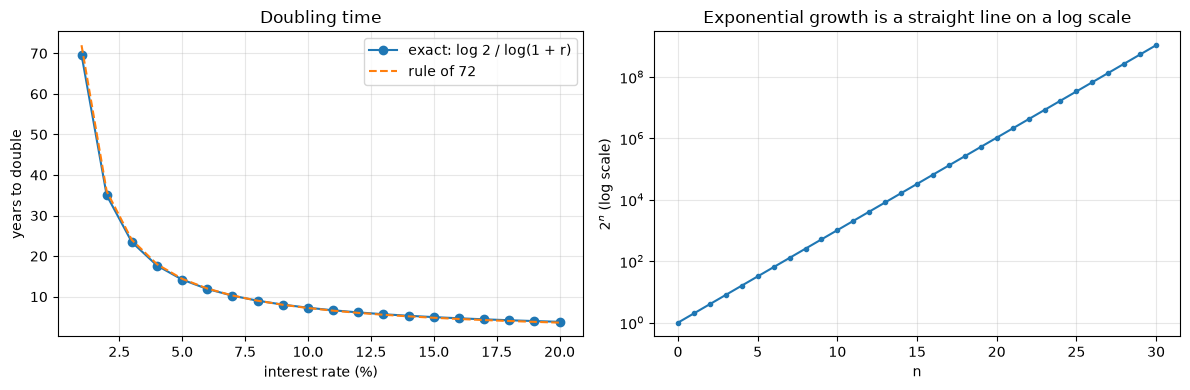

Doubling at 8%: 9.006 years | rule of 72: 9.0
C-14, 10% left: 19035 years
pH for [H+] = 1e-3: 3.0 | 1000× intensity: 30.0 dB | M7 vs M5 amplitude: 100


In [12]:
rates = np.arange(1, 21)
exact = np.log(2) / np.log(1 + rates / 100)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(rates, exact, "o-", label="exact: log 2 / log(1 + r)")
plt.plot(rates, 72 / rates, "--", label="rule of 72")
plt.xlabel("interest rate (%)"); plt.ylabel("years to double"); plt.grid(alpha=0.3); plt.legend()
plt.title("Doubling time")

n = np.arange(0, 31)
ax = plt.subplot(1, 2, 2)
ax.plot(n, 2.0**n, "o-", ms=3)
ax.set_yscale("log"); ax.set_xlabel("n"); ax.set_ylabel("$2^n$ (log scale)"); ax.grid(alpha=0.3, which="both")
ax.set_title("Exponential growth is a straight line on a log scale")
plt.tight_layout(); plt.show()

print("Doubling at 8%:", round(math.log(2) / math.log(1.08), 3), "years | rule of 72:", 72 / 8)
print("C-14, 10% left:", round(5730 * math.log10(10) / math.log10(2)), "years")
print("pH for [H+] = 1e-3:", -math.log10(1e-3), "| 1000× intensity:", 10 * math.log10(1000), "dB | M7 vs M5 amplitude:", 10**(7 - 5))

## 13. Common Mistakes

| Mistake | Correct |
|---------|---------|
| $\log(m + n) = \log m + \log n$ | $\log(mn) = \log m + \log n$; $\log(m + n)$ does not simplify |
| $\log(m - n) = \dfrac{\log m}{\log n}$ | $\log\dfrac{m}{n} = \log m - \log n$ |
| $\dfrac{\log m}{\log n} = \log m - \log n$ | $\dfrac{\log m}{\log n} = \log_n m$ (change of base) |
| $(\log m)^2 = 2\log m$ | Only $\log(m^2) = 2\log m$ |
| $\log_a 0 = 0$ or $\log$ of a negative number | Undefined — the argument must be $> 0$ |
| Not checking the domain at the end | Always reject roots that make an argument $\le 0$ or a base $\le 0$ or $= 1$ |
| Keeping the inequality sign with base $< 1$ | Base $< 1$ **reverses** the inequality |
| $\log x^2 = 2\log x$ for all $x$ | $\log x^2 = 2\log\lvert x\rvert$ |
| Writing $\log 0.00456 = \bar{3}.341$ | Mantissa must be positive: $\bar{3}.6590$ |
| $\ln$ and $\log$ are the same | $\ln$ is base $e$; $\log$ is usually base 10 |
| $\log_a b \cdot \log_c d = \log_{ac} bd$ | No such rule; use change of base |

## 14. Formula Sheet

| Item | Formula |
|------|---------|
| Definition | $\log_a N = x \iff a^x = N$ ($a > 0, a \neq 1, N > 0$) |
| Special values | $\log_a 1 = 0$, $\log_a a = 1$, $a^{\log_a N} = N$ |
| Product | $\log_a mn = \log_a m + \log_a n$ |
| Quotient | $\log_a \dfrac{m}{n} = \log_a m - \log_a n$ |
| Power | $\log_a m^k = k\log_a m$ |
| Change of base | $\log_a N = \dfrac{\log_b N}{\log_b a}$ |
| Reciprocal | $\log_a b = \dfrac{1}{\log_b a}$ |
| Chain | $\log_a b \cdot \log_b c = \log_a c$ |
| Power of base | $\log_{a^m} b^n = \dfrac{n}{m}\log_a b$ |
| Swap | $a^{\log_b c} = c^{\log_b a}$ |
| ln ↔ log | $\ln N \approx 2.303\log N$ |
| Inequality, base $> 1$ | $\log_a f > \log_a g \iff f > g > 0$ |
| Inequality, base $< 1$ | $\log_a f > \log_a g \iff 0 < f < g$ |
| Characteristic | $d - 1$ for $d$ digits; $-(z + 1)$ for $z$ zeros after the decimal point |
| Number of digits in $N$ | $\lfloor\log N\rfloor + 1$ |
| Doubling time | $\dfrac{\log 2}{\log(1 + r)} \approx \dfrac{72}{r\%}$ |
| pH / dB / Richter | $-\log[\text{H}^+]$ / $10\log\dfrac{I}{I_0}$ / $\log\dfrac{A}{A_0}$ |
| Values | $\log 2 \approx 0.3010$, $\log 3 \approx 0.4771$, $\log 7 \approx 0.8451$, $\ln 2 \approx 0.6931$ |

## 15. Practice Problems (with Answers)

### Level 1 — Basics
1. Write $5^3 = 125$ in log form and $\log_2 \tfrac{1}{16} = -4$ in exponential form.
2. Evaluate $\log_{\sqrt{3}} 81$.
3. Evaluate $\log_{0.2} 25$.
4. Simplify $\log 8 + \log 125 - \log 10$.
5. Given $\log 2 = 0.3010$, $\log 3 = 0.4771$, find $\log 18$ and $\log 45$.
6. Evaluate $\log_3 5 \cdot \log_{25} 27$.
7. Evaluate $7^{\log_7 4} + 2^{\log_2 3}$.

### Level 2 — Standard
8. Solve $\log_5(x - 2) = 2$.
9. Solve $3^x = 20$ (to 4 decimal places).
10. Solve $\log_2 x + \log_2(x + 2) = 3$.
11. Solve $\log(x + 1) - \log(x - 1) = \log 3$.
12. Solve $9^x - 4 \cdot 3^x + 3 = 0$.
13. Solve $(\log_3 x)^2 - \log_3 x - 2 = 0$.
14. Solve $\log_x 64 = 3$.

### Level 3 — Challenge
15. Solve $\log_2(3x - 2) \le 2$.
16. Solve $\log_{0.5}(x + 1) > 1$.
17. How many digits does $2^{64}$ have?
18. How many whole years does money take to at least double at 6% compound interest per year?
19. Find the pH of a solution with $[\text{H}^+] = 2.5 \times 10^{-5}$.
20. If $a^2 + b^2 = 7ab$ ($a, b > 0$), prove $\log\dfrac{a + b}{3} = \dfrac{1}{2}(\log a + \log b)$.

<details>
<summary><strong>Answers</strong> (click to expand)</summary>

1. $\log_5 125 = 3$; $\;2^{-4} = \tfrac{1}{16}$
2. $(\sqrt{3})^8 = 81$ → $8$
3. $\left(\tfrac{1}{5}\right)^x = 25$ → $-2$
4. $\log\dfrac{1000}{10} = 2$
5. $\log 18 = 0.3010 + 2(0.4771) = 1.2552$; $\;\log 45 = \log\dfrac{9 \cdot 10}{2} = 0.9542 + 1 - 0.3010 = 1.6532$
6. $\dfrac{\ln 5}{\ln 3} \cdot \dfrac{3\ln 3}{2\ln 5} = \dfrac{3}{2}$
7. $4 + 3 = 7$
8. $x - 2 = 25 \Rightarrow x = 27$
9. $x = \dfrac{\log 20}{\log 3} \approx 2.7268$
10. $x^2 + 2x - 8 = 0 \Rightarrow x = 2$ (reject $-4$)
11. $\dfrac{x + 1}{x - 1} = 3 \Rightarrow x = 2$
12. $t = 3^x$: $t^2 - 4t + 3 = 0 \Rightarrow t = 1, 3 \Rightarrow x = 0, 1$
13. $\log_3 x = 2$ or $-1$ → $x = 9$ or $\tfrac{1}{3}$
14. $x^3 = 64 \Rightarrow x = 4$
15. $0 < 3x - 2 \le 4 \Rightarrow \tfrac{2}{3} < x \le 2$
16. $0 < x + 1 < 0.5 \Rightarrow -1 < x < -0.5$
17. $64 \times 0.30103 = 19.27$ → $20$ digits
18. $n \ge \dfrac{\log 2}{\log 1.06} \approx 11.9$ → $12$ years
19. $5 - \log 2.5 = 5 - 0.3979 \approx 4.60$
20. $(a + b)^2 = 9ab \Rightarrow \left(\tfrac{a + b}{3}\right)^2 = ab$; take logs (proof in Section 6)

</details>

In [13]:
# Check the practice answers
xp = sp.symbols("xp", positive=True)
L = lambda v, b=10: sp.log(v, b)
s = lambda e: sp.nsimplify(sp.simplify(e))
print(" 1.", sp.simplify(L(125, 5)), sp.Rational(2)**-4)
print(" 2.", s(L(81, sp.sqrt(3))))
print(" 3.", s(L(25, sp.Rational(1, 5))))
print(" 4.", s(L(8) + L(125) - L(10)))
print(" 5.", round(0.3010 + 2*0.4771, 4), round(2*0.4771 + 1 - 0.3010, 4))
print(" 6.", s(L(5, 3) * L(27, 25)))
print(" 7.", s(7**L(4, 7) + 2**L(3, 2)))
print(" 8.", sp.solve(xp - 2 - 25, xp))
print(" 9.", round(math.log(20, 3), 4))
print("10.", [v for v in sp.solve(xp*(xp + 2) - 8, xp)])
print("11.", [v for v in sp.solve((xp + 1) - 3*(xp - 1), xp) if v > 1])
print("12.", sp.solve(9**x - 4*3**x + 3, x))
print("13.", [3**v for v in sp.solve(t**2 - t - 2, t)])
print("14.", sp.solve(xp**3 - 64, xp))
print("15.", sp.reduce_inequalities([3*x - 2 > 0, 3*x - 2 <= 4], x))
print("16.", sp.reduce_inequalities([x + 1 > 0, x + 1 < sp.Rational(1, 2)], x))
print("17.", len(str(2**64)))
print("18.", next(n for n in range(1, 100) if 1.06**n >= 2), f"(1.06^11 = {1.06**11:.4f}, 1.06^12 = {1.06**12:.4f})")
print("19.", round(-math.log10(2.5e-5), 4))
a_, b_ = sp.symbols("a b", positive=True)
print("20.", sp.expand((a_ + b_)**2 - 9*a_*b_ - (a_**2 + b_**2 - 7*a_*b_)), "(= 0, so (a+b)^2 = 9ab whenever a^2 + b^2 = 7ab)")

 1. 3 1/16
 2. 8
 3. -2
 4. 2
 5. 1.2552 1.6532
 6. 3/2
 7. 7
 8. [27]
 9. 2.7268
10. [2]
11. [2]
12. [0, 1]
13. [1/3, 9]
14. [4]
15. (x <= 2) & (2/3 < x)
16. (-1 < x) & (x < -1/2)
17. 20
18. 12 (1.06^11 = 1.8983, 1.06^12 = 2.0122)
19. 4.6021
20. 0 (= 0, so (a+b)^2 = 9ab whenever a^2 + b^2 = 7ab)
